#### Business Questions
1. Which category has the highest installs
 2. Which category has the highest reviews
 3. Which app has the highest installs in each category
 4. Which category has the best and least rating
 5. Are expensive apps rated higher?
 6. Do bigger apps get more installs
 7. How many apps on playstore are rated 5 stars

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset 

In [76]:
gps=pd.read_csv('raw_file.csv')
gps.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [8]:
gps.shape
gps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


##  Checking Missing Values 

In [9]:
gps.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

### Observation
Dataset has a lot of missing values

# Data Cleaning

In [10]:
gps['Reviews'].unique()
gps[~gps['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [11]:
gps.drop(gps.index[10472],inplace=True)
gps['Reviews']=gps['Reviews'].astype(int)

In [77]:
gps['Size'].unique()


array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [13]:
gps['Size']=gps['Size'].str.replace('M','e6',regex=False)
gps['Size']=gps['Size'].str.replace('k','e3',regex=False)
gps['Size']=gps['Size'].replace('Varies with device',0)
gps['Size']=pd.to_numeric(gps['Size'],errors='coerce')  
gps['Size']

0        19000000.0
1        14000000.0
2         8700000.0
3        25000000.0
4         2800000.0
            ...    
10836    53000000.0
10837     3600000.0
10838     9500000.0
10839           0.0
10840    19000000.0
Name: Size, Length: 10840, dtype: float64

In [14]:
gps['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [15]:
gps['Installs']=gps['Installs'].str.replace('+','', regex=False) 
gps['Installs']=gps['Installs'].str.replace(',','', regex=False)
gps['Installs'].unique()

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0'], dtype=object)

In [16]:
gps['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [17]:
gps['Price']=gps['Price'].str.replace('$','', regex=False)
gps['Price']=gps['Price'].astype(float)
gps['Price'].unique()

array([  0.  ,   4.99,   3.99,   6.99,   1.49,   2.99,   7.99,   5.99,
         3.49,   1.99,   9.99,   7.49,   0.99,   9.  ,   5.49,  10.  ,
        24.99,  11.99,  79.99,  16.99,  14.99,   1.  ,  29.99,  12.99,
         2.49,  10.99,   1.5 ,  19.99,  15.99,  33.99,  74.99,  39.99,
         3.95,   4.49,   1.7 ,   8.99,   2.  ,   3.88,  25.99, 399.99,
        17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,   1.61,   2.5 ,
         1.59,   6.49,   1.29,   5.  ,  13.99, 299.99, 379.99,  37.99,
        18.99, 389.99,  19.9 ,   8.49,   1.75,  14.  ,   4.85,  46.99,
       109.99, 154.99,   3.08,   2.59,   4.8 ,   1.96,  19.4 ,   3.9 ,
         4.59,  15.46,   3.04,   4.29,   2.6 ,   3.28,   4.6 ,  28.99,
         2.95,   2.9 ,   1.97, 200.  ,  89.99,   2.56,  30.99,   3.61,
       394.99,   1.26,   1.2 ,   1.04])

In [18]:
gps['Installs']=gps['Installs'].astype(float)
gps['Installs'].unique()

array([1.e+04, 5.e+05, 5.e+06, 5.e+07, 1.e+05, 5.e+04, 1.e+06, 1.e+07,
       5.e+03, 1.e+08, 1.e+09, 1.e+03, 5.e+08, 5.e+01, 1.e+02, 5.e+02,
       1.e+01, 1.e+00, 5.e+00, 0.e+00])

In [19]:
gps['Last Updated']=pd.to_datetime(gps['Last Updated']) 
gps['Last Updated']

0       2018-01-07
1       2018-01-15
2       2018-08-01
3       2018-06-08
4       2018-06-20
           ...    
10836   2017-07-25
10837   2018-07-06
10838   2017-01-20
10839   2015-01-19
10840   2018-07-25
Name: Last Updated, Length: 10840, dtype: datetime64[ns]

In [20]:
gps.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up


In [21]:
gps.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            10840 non-null  float64       
 5   Installs        10840 non-null  float64       
 6   Type            10839 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(7)
memory usage: 1.2+ MB


In [24]:
gps_copy=gps.copy() 
gps_copy.to_csv('Cleaned data/googlecleaned.csv')

## Exploratory Data Analysis

In [3]:
gps_copy=pd.read_csv('Cleaned data/googlecleaned.csv')
gps_copy.drop('Unnamed: 0',axis=1,inplace=True)
gps_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000,10000,Free,0.0,Everyone,Art & Design,07/01/2018,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,15/01/2018,2.0.0,4.0.3 and up


## Duplicate check

In [67]:
gps_copy[gps_copy.duplicated('App')]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,0,5000000,Free,0.0,Everyone,Business,26/02/2018,Varies with device,4.0.3 and up
236,Box,BUSINESS,4.2,159872,0,10000000,Free,0.0,Everyone,Business,31/07/2018,Varies with device,Varies with device
239,Google My Business,BUSINESS,4.4,70991,0,5000000,Free,0.0,Everyone,Business,24/07/2018,2.19.0.204537701,4.4 and up
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37000000,10000000,Free,0.0,Everyone,Business,20/07/2018,4.1.28165.0716,4.0 and up
261,join.me - Simple Meetings,BUSINESS,4.0,6989,0,1000000,Free,0.0,Everyone,Business,16/07/2018,4.3.0.508,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10714,FarmersOnly Dating,DATING,3.0,1145,1400000,100000,Free,0.0,Mature 17+,Dating,25/02/2016,2.2,4.0 and up
10719,Firefox Focus: The privacy browser,COMMUNICATION,4.4,36981,4000000,1000000,Free,0.0,Everyone,Communication,06/07/2018,5.2,5.0 and up
10729,FP Notebook,MEDICAL,4.5,410,60000000,50000,Free,0.0,Everyone,Medical,24/03/2018,2.1.0.372,4.4 and up
10752,Slickdeals: Coupons & Shopping,SHOPPING,4.5,33599,12000000,1000000,Free,0.0,Everyone,Shopping,30/07/2018,3.9,4.4 and up


# Observation
The dataset has duplicate records

In [68]:
gps_copy=gps_copy.drop_duplicates(subset=['App'],keep='first')

In [71]:
gps_copy.groupby('Category')['Installs'].sum().sort_values(ascending=False)

Category
GAME                   18878924415
COMMUNICATION          11038276251
SOCIAL                  8487867902
TOOLS                   8001771915
PHOTOGRAPHY             7649147655
PRODUCTIVITY            5793091369
NEWS_AND_MAGAZINES      5369217760
FAMILY                  4427941505
VIDEO_PLAYERS           3926902720
TRAVEL_AND_LOCAL        2894887146
ENTERTAINMENT           2113660000
BOOKS_AND_REFERENCE     1665969576
PERSONALIZATION         1532494782
SHOPPING                1400348785
HEALTH_AND_FITNESS      1144022512
SPORTS                  1096474498
BUSINESS                 697164865
LIFESTYLE                503823539
MAPS_AND_NAVIGATION      503281890
FINANCE                  455348734
WEATHER                  361100520
EDUCATION                352952000
FOOD_AND_DRINK           211798751
DATING                   140926107
ART_AND_DESIGN           114338100
HOUSE_AND_HOME            97212461
AUTO_AND_VEHICLES         53130211
LIBRARIES_AND_DEMO        52995910
COMICS     

In [70]:
gps_copy.groupby('Category')['Reviews'].sum().sort_values(ascending=False)

Category
GAME                   622298709
COMMUNICATION          285811368
TOOLS                  229356578
SOCIAL                 227927801
FAMILY                 143825488
PHOTOGRAPHY            105351270
VIDEO_PLAYERS           67484568
PRODUCTIVITY            55590649
PERSONALIZATION         53543080
SHOPPING                44551730
SPORTS                  35348813
ENTERTAINMENT           34762650
TRAVEL_AND_LOCAL        26819741
NEWS_AND_MAGAZINES      23130228
HEALTH_AND_FITNESS      21361355
MAPS_AND_NAVIGATION     17729148
BOOKS_AND_REFERENCE     16721314
EDUCATION               13364148
FINANCE                 12662106
WEATHER                 12295164
LIFESTYLE               11832671
BUSINESS                 9890245
FOOD_AND_DRINK           6325028
DATING                   3623544
COMICS                   2342071
HOUSE_AND_HOME           1929847
ART_AND_DESIGN           1419203
MEDICAL                  1182971
AUTO_AND_VEHICLES        1163666
PARENTING                 958331
L

In [69]:
cai = gps_copy.groupby(['Category' ,'App'])['Installs'].sum().reset_index()     
cai = cai.sort_values('Installs', ascending = False)
cai


,Category,App,Installs
4773,GAME,Subway Surfers,6000000000
6388,NEWS_AND_MAGAZINES,Google News,4000000000
7919,SOCIAL,Instagram,4000000000
7080,PHOTOGRAPHY,Google Photos,4000000000
9311,TRAVEL_AND_LOCAL,Google Street View,1000000000
...,...,...,...
9275,TRAVEL_AND_LOCAL,EG | Explore Folegandros,0
6020,MEDICAL,EP Cook Book,0
3662,FINANCE,Eu sou Rico,0
1797,FAMILY,Ain Arabic Kids Alif Ba ta,0


In [72]:
gps_copy.groupby('Category')['Rating'].mean().sort_values(ascending=False)

Category
EVENTS                 4.435556
EDUCATION              4.364407
ART_AND_DESIGN         4.357377
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
PARENTING              4.300000
BEAUTY                 4.278571
GAME                   4.247368
SOCIAL                 4.247291
WEATHER                4.243056
HEALTH_AND_FITNESS     4.243033
SHOPPING               4.230000
SPORTS                 4.216154
AUTO_AND_VEHICLES      4.190411
PRODUCTIVITY           4.183389
COMICS                 4.181481
FAMILY                 4.179664
LIBRARIES_AND_DEMO     4.178125
FOOD_AND_DRINK         4.172340
MEDICAL                4.166552
PHOTOGRAPHY            4.157414
HOUSE_AND_HOME         4.150000
ENTERTAINMENT          4.135294
NEWS_AND_MAGAZINES     4.121569
COMMUNICATION          4.121484
FINANCE                4.115563
BUSINESS               4.098479
LIFESTYLE              4.093355
TRAVEL_AND_LOCAL       4.069519
VIDEO_PLAYERS          4.044595
TOOLS                  4.039554

In [73]:
gps_copy[['Price','Rating']].corr()

,Price,Rating
Price,1.000000,-0.021199
Rating,-0.021199,1.000000


In [74]:
gps_copy[['Size','Installs']].corr()

,Size,Installs
Size,1.000000,0.003937
Installs,0.003937,1.000000


In [112]:
rating = gps_copy.groupby(['Category','Installs', 'App'])['Rating'].sum().sort_values(ascending = False).reset_index()

toprating_apps = rating[rating.Rating == 5.0]
print("Number of 5 rated apps",toprating_apps.shape[0])
toprating_apps.head(1)

Number of 5 rated apps 271


,Category,Installs,App,Rating
0,FAMILY,1000,CS & IT Interview Questions,5.0


## Visualization

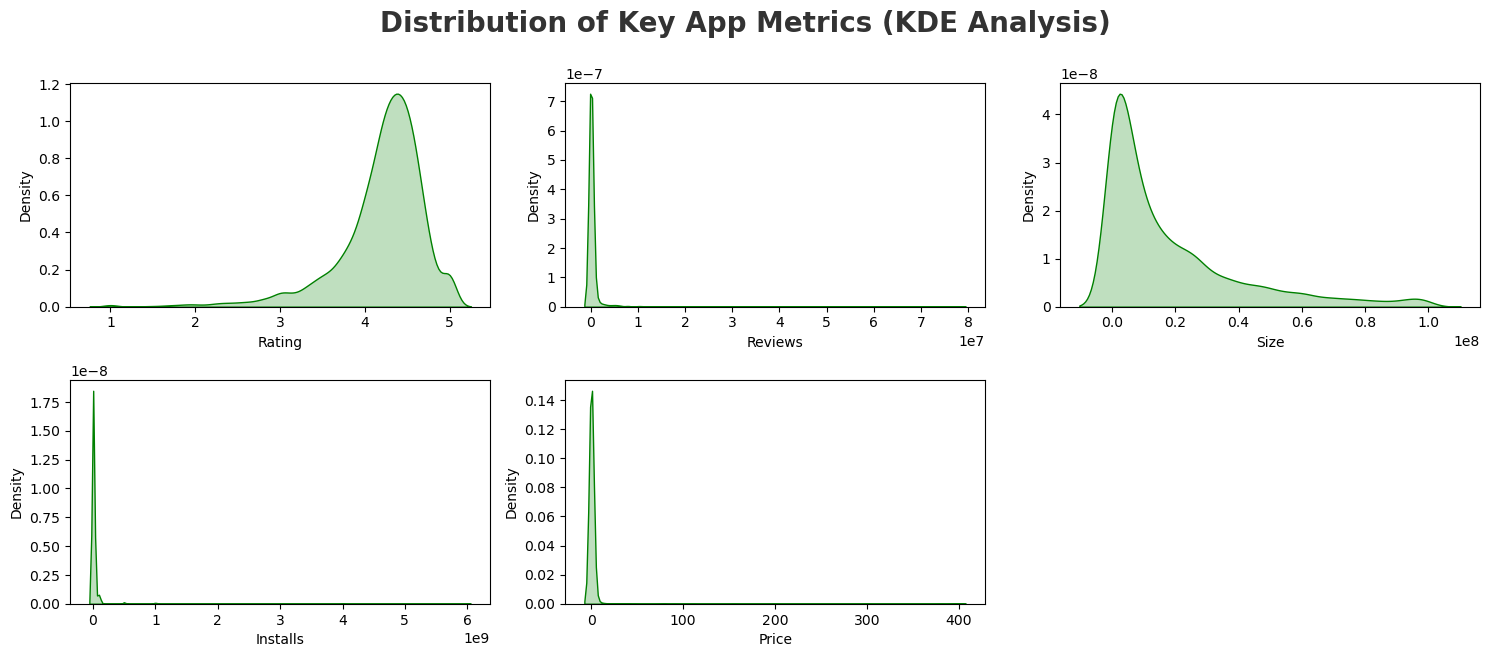

In [4]:
numeric_features = [feature for feature in gps_copy.columns if gps_copy[feature].dtype != 'O']
categorical_features = [feature for feature in gps_copy.columns if gps_copy[feature].dtype == 'O']

plt.figure(figsize=(15, 15))
plt.suptitle('Distribution of Key App Metrics (KDE Analysis)', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=gps_copy[numeric_features[i]],fill=True, color='g')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

## Observations
- Rating is left skewed 
- Size, Installs, Price and Reviews are right skewed

<Figure size 2000x1500 with 0 Axes>

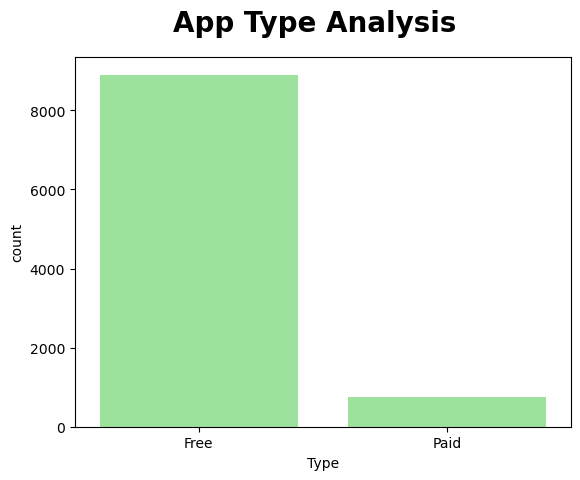

In [80]:
sns.countplot(data=gps_copy,x='Type',color='lightgreen')
plt.suptitle('App Type Analysis',fontsize=20,fontweight='bold')
plt.Figure(figsize=(20,15))

Text(0.5, 1.0, 'Most Installed Categories in Play Store')

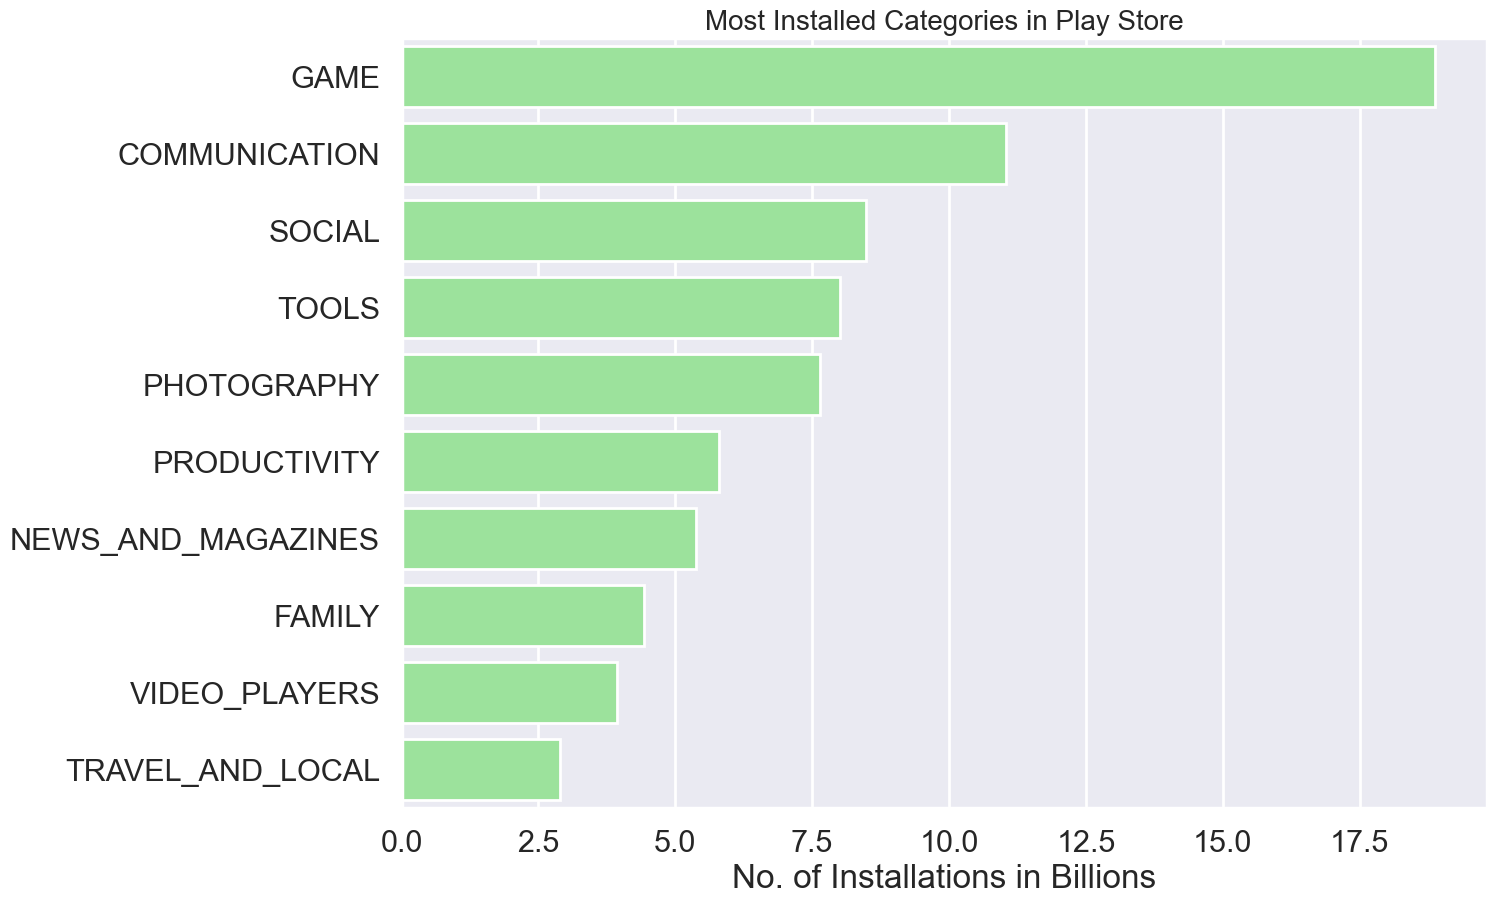

In [105]:
category_install = gps_copy.groupby(['Category'])['Installs'].sum().sort_values(ascending = False).reset_index()
category_install.Installs = category_install.Installs/1000000000
cib = category_install.head(10)
plt.figure(figsize = (14,10))


ax = sns.barplot(x = 'Installs' , y = 'Category' , data = cib,color= 'lightgreen')
ax.set_xlabel('No. of Installations in Billions')
ax.set_ylabel('')
ax.set_title("Most Installed Categories in Play Store", size = 20)

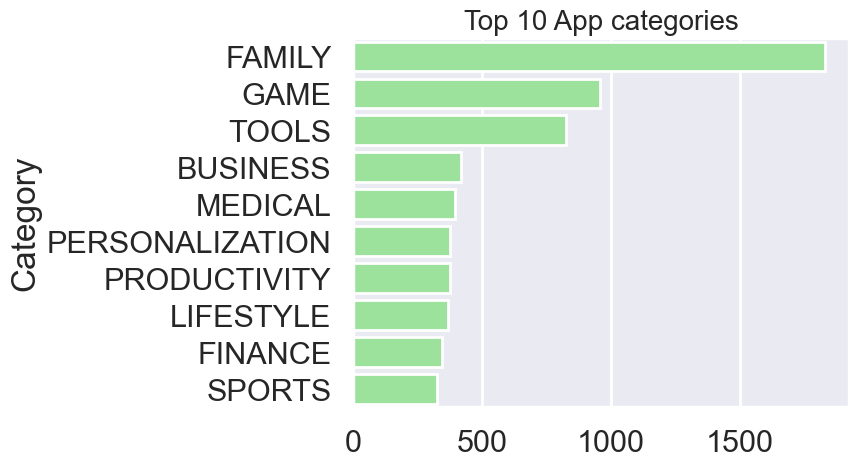

<Figure size 1400x1000 with 0 Axes>

In [108]:
ax = sns.barplot(y=category.index[:10],x='count',data = category[:10],color='lightgreen')
ax.set_title('Top 10 App categories',size=20)
ax.set_xlabel('')
plt.figure(figsize = (14,10))
plt.show()






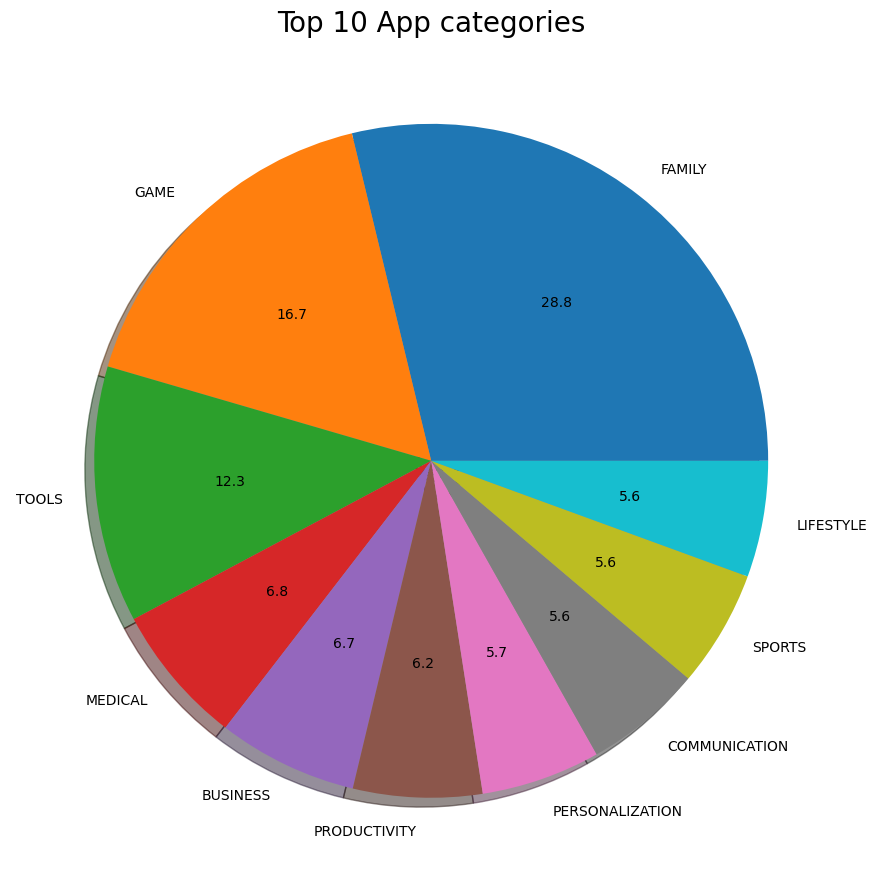

In [9]:
category_count=gps_copy['Category'].value_counts().sort_values(ascending=False) 
category_count.head(10).plot.pie(y=gps_copy['Category'],figsize=(9,16),autopct='%1.1f',shadow=True)
plt.title('Top 10 App categories', size=20)
plt.ylabel('')
plt.tight_layout()


## Insights
1. Out of all the categories "GAME" has the most number of Installations.
2. GAME is also  the most reviewed Category in Google App store
3. in each category:
- Most installed game is Subway Surfers.
- Most installed  News and Magazine app is Google News.
- Most installed Photography app is Google Photos.
- Most installed Travel and Local app is Google Street View.

4. 'Event' has more rating and 'Dating' with the least rating
5. Price has no relationship with rating with a corelation of -0.02. So expensive apps aren't rated higher.
6. App size does not strongly correlate with ratings
7. There are 271 five star rated apps on Google Play store
- Top most is 'CS & IT Interview Questions' from 'Family' Category